In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os 
from glob import glob
import pandas as pd
import json

In [3]:
def read_settings(fin):
    fin = fin.replace('\\', '/')
    # print(fin)
    df_settings = pd.read_csv(fin, sep=':', names=['setting', 'value'])
    df_settings = df_settings.set_index('setting', drop=True)
    return df_settings

def read_results(f, powers):
    df_results = pd.read_csv(f)
    df_results['avg_counts'] = df_results['avg_counts'] / powers[f]
    df_results['fit_exp'] = df_results['fit_exp'] / powers[f]
    sample = f.split('\\')[-3].replace('Rhodamine-B', 'RhB').replace(' 140525', '')
    return df_results, sample

# Prepare paths

In [4]:
ROOT_DIR = "C:\\Users\\owner\\Documents\\offline_data\\img\\"
path14 = ROOT_DIR + 'time\\14-05-25\\'
path15 = ROOT_DIR + 'time\\15-05-25\\'
path20 = ROOT_DIR + 'time\\20-05-25\\'
subdirs14 = next(os.walk(path14))[1]
subdirs15 = next(os.walk(path15))[1]
subdirs20 = next(os.walk(path20))[1]
subdirs20

['Rhodamine-B 100 nM 140525 (B)',
 'Rhodamine-B 50 nM 140525 (B)',
 'Rhodamine-B 500 nM 140525 (B)']

In [5]:
results_files = []
results_files.append(glob(path14 + '**/**/results_roi.csv'))
results_files.append(glob(path15 + '**/**/results_roi.csv'))
results_files.append(glob(path20 + '**/**/results_roi.csv'))
results_files = [item for sublist in results_files for item in sublist]
results_files

['C:\\Users\\owner\\Documents\\offline_data\\img\\time\\14-05-25\\Rhodamine-B 500 nM 140525 (A)\\03-filt7-575nm\\results_roi.csv',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\14-05-25\\Rhodamine-B 500 nM 140525 (A)\\04-filt6-550nm\\results_roi.csv',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 1 µM 140525 (B)\\01-filt6-550nm\\results_roi.csv',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 1 µM 140525 (B)\\02-filt7-575nm\\results_roi.csv',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 10 nM 140525\\01-filt7-575nm\\results_roi.csv',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 10 nM 140525\\02-filt6-550nm_lights_off\\results_roi.csv',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 10 nM 140525\\03-filt6-550nm_lights_on\\results_roi.csv',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 10 

In [6]:
results_files[0].split('\\')[-3], results_files[0].split('\\')[-2], results_files[0].split('\\')[-1]

('Rhodamine-B 500 nM 140525 (A)', '03-filt7-575nm', 'results_roi.csv')

In [7]:
path_f6 = []
path_f7 = []
path_f8 = []

for i in range(len(results_files)):
    filter_string = results_files[i].split('\\')[-2]
    sample_string = results_files[i].split('\\')[-3]
    if 'filt6' in filter_string:
        path_f6.append(results_files[i])
    elif 'filt7' in filter_string:
        path_f7.append(results_files[i])
    elif 'filt8' in filter_string:
        path_f8.append(results_files[i])
path_f7

['C:\\Users\\owner\\Documents\\offline_data\\img\\time\\14-05-25\\Rhodamine-B 500 nM 140525 (A)\\03-filt7-575nm\\results_roi.csv',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 1 µM 140525 (B)\\02-filt7-575nm\\results_roi.csv',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 10 nM 140525\\01-filt7-575nm\\results_roi.csv',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 10 nM 140525\\04-filt7-575nm\\results_roi.csv',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 100 nM 140525 (A)\\02-filt7-575nm\\results_roi.csv',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 100 nM 140525 (A)\\03-filt7-575nm\\results_roi.csv',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 50 nM 140525 (A)\\01-filt7-575nm\\results_roi.csv',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\20-05-25\\Rhodamine-B 50 nM 140525 (B)\\

In [8]:
path_f6 = [
  'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 1 µM 140525 (B)\\01-filt6-550nm\\results_roi.csv',
  'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\14-05-25\\Rhodamine-B 500 nM 140525 (A)\\04-filt6-550nm\\results_roi.csv',
  'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\20-05-25\\Rhodamine-B 500 nM 140525 (B)\\02-filt6-550nm\\results_roi.csv',
  'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 100 nM 140525 (A)\\01-filt6-550nm\\results_roi.csv',
  'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\20-05-25\\Rhodamine-B 100 nM 140525 (B)\\02-filt6-550nm\\results_roi.csv',
  'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 50 nM 140525 (A)\\02-filt6-550nm\\results_roi.csv',
  'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\20-05-25\\Rhodamine-B 50 nM 140525 (B)\\02-filt6-550nm\\results_roi.csv',
  'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 10 nM 140525\\02-filt6-550nm_lights_off\\results_roi.csv',
  'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 10 nM 140525\\03-filt6-550nm_lights_on\\results_roi.csv',
]

In [118]:
path_f7 = [
  'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 1 µM 140525 (B)\\02-filt7-575nm\\results_roi.csv',
  'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\14-05-25\\Rhodamine-B 500 nM 140525 (A)\\03-filt7-575nm\\results_roi.csv',
  'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\20-05-25\\Rhodamine-B 500 nM 140525 (B)\\01-filt7-575nm\\results_roi.csv',
  'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 100 nM 140525 (A)\\02-filt7-575nm\\results_roi.csv',
  'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 50 nM 140525 (A)\\01-filt7-575nm\\results_roi.csv',
  'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\20-05-25\\Rhodamine-B 50 nM 140525 (B)\\01-filt7-575nm\\results_roi.csv',
  'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 10 nM 140525\\01-filt7-575nm\\results_roi.csv',
  ]

## Normalize by power

In [103]:
np.mean(powers)

338.32500000000005

In [173]:
powers = {}
for f in results_files:
    power_file = f.replace('results_roi.csv', 'settings.json')
    df_settings = read_settings(power_file)
    p = df_settings.loc['POWER(uW)'].values[0]
    p = float(p)
    if p > 0:
        powers[f] = p / 338.25   # Normalization to 338.25 uW (mean power)
    else:
        print(p)
        powers[f] = 1   # Imputation, mean power in other measurements


0.0
0.0
0.0


In [174]:
powers

{'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\14-05-25\\Rhodamine-B 500 nM 140525 (A)\\03-filt7-575nm\\results_roi.csv': 1,
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\14-05-25\\Rhodamine-B 500 nM 140525 (A)\\04-filt6-550nm\\results_roi.csv': 1,
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 1 µM 140525 (B)\\01-filt6-550nm\\results_roi.csv': 1,
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 1 µM 140525 (B)\\02-filt7-575nm\\results_roi.csv': 1.0891352549889135,
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 10 nM 140525\\01-filt7-575nm\\results_roi.csv': 0.8053215077605321,
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 10 nM 140525\\02-filt6-550nm_lights_off\\results_roi.csv': 0.8005912786400592,
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 10 nM 140525\\03-filt6-550nm_lights_on\\results_roi.csv': 0.8218773096

# Filter 6

[Text(0.5, 0, 'Time (min)'),
 Text(0, 0.5, 'Counts'),
 Text(0.5, 1.0, 'Filter 6')]

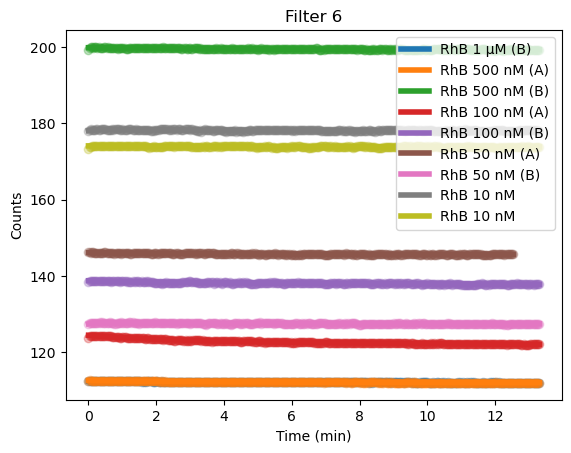

In [121]:
colors = []
for i,f in enumerate(path_f6):
    df_results, sample_name = read_results(f, powers)
    col = plt.plot(df_results['time'], df_results['avg_counts'], 'o', alpha=0.3)[0].get_color()
    colors.append(col)
    plt.plot(df_results['time'], df_results['fit_exp'], '-', color=col, ms=10, lw=4, label=sample_name)
plt.legend()
plt.gca().set(xlabel='Time (min)', ylabel='Counts', title='Filter 6', ) 

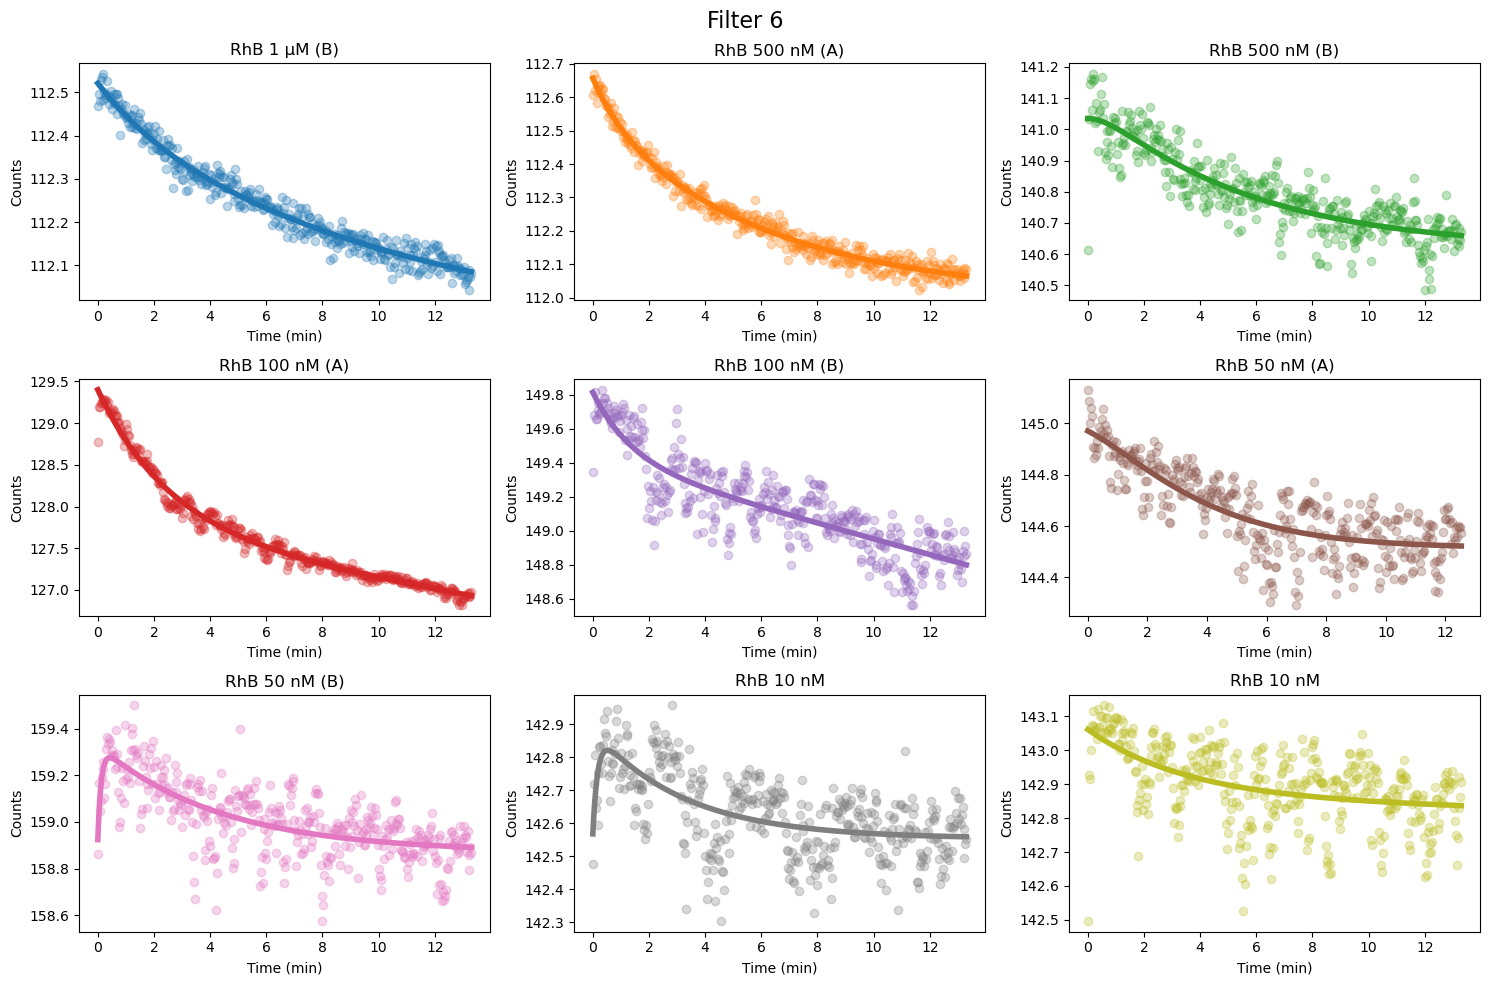

In [127]:
fig, ax = plt.subplots(3, 3, figsize=(15, 10))
for i,f in enumerate(path_f6):
    j, k = divmod(i, 3)
    df_results = pd.read_csv(f)
    sample = f.split('\\')[-3].replace('Rhodamine-B', 'RhB').replace(' 140525', '')
    col = colors[i]
    ax[j,k].plot(df_results['time'], df_results['avg_counts'], 'o', alpha=0.3, color=col)
    ax[j,k].plot(df_results['time'], df_results['fit_exp'], '-', color=col, ms=10, lw=4, label=sample)
    ax[j,k].set(xlabel='Time (min)', ylabel='Counts' ,title = sample)
plt.suptitle('Filter 6', fontsize=16)
plt.tight_layout()

# Filter 7

[Text(0.5, 0, 'Time (s)'),
 Text(0, 0.5, 'Counts'),
 Text(0.5, 1.0, 'Rhodamine B, Filter 7')]

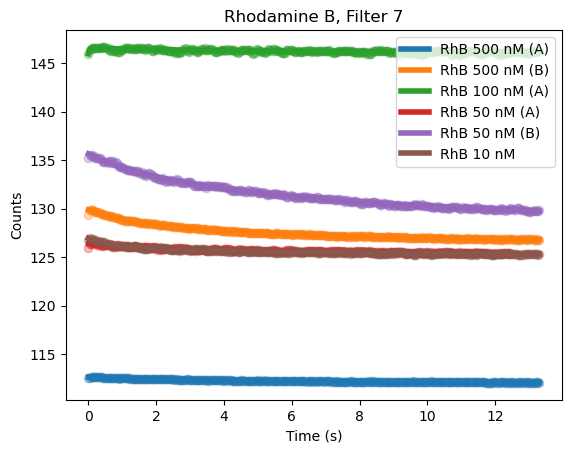

In [122]:
for i,f in enumerate(path_f7[1:]):
    df_results = pd.read_csv(f)
    sample = f.split('\\')[-3].replace('Rhodamine-B', 'RhB').replace(' 140525', '')
    col = plt.plot(df_results['time'], df_results['avg_counts'], 'o', alpha=0.3)[0].get_color()
    plt.plot(df_results['time'], df_results['fit_exp'], '-', color=col, ms=10, lw=4, label=sample)
plt.legend()
plt.gca().set(xlabel='Time (s)', ylabel='Counts', title='Rhodamine B, Filter 7')

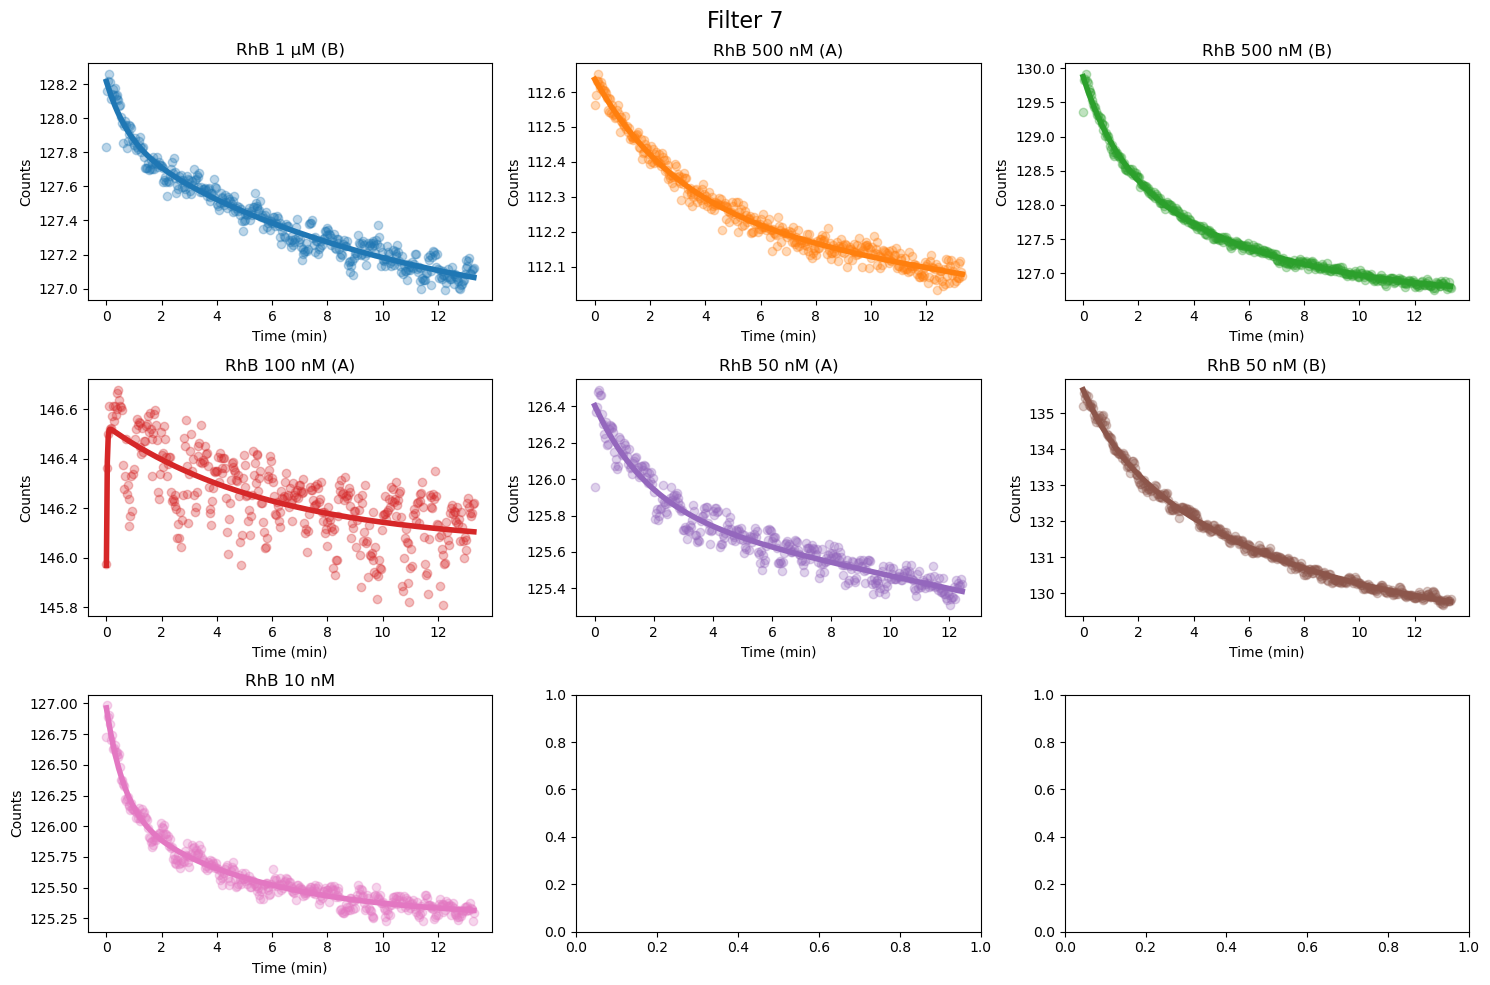

In [125]:
fig, ax = plt.subplots(3, 3, figsize=(15, 10))
for i,f in enumerate(path_f7):
    j, k = divmod(i, 3)
    df_results = pd.read_csv(f)
    sample = f.split('\\')[-3].replace('Rhodamine-B', 'RhB').replace(' 140525', '')
    col = colors[i]
    ax[j,k].plot(df_results['time'], df_results['avg_counts'], 'o', alpha=0.3, color=col)
    ax[j,k].plot(df_results['time'], df_results['fit_exp'], '-', color=col, ms=10, lw=4, label=sample)
    ax[j,k].set(xlabel='Time (min)', ylabel='Counts' ,title = sample)
plt.suptitle('Filter 7', fontsize=16)
plt.tight_layout()


# Filter 8

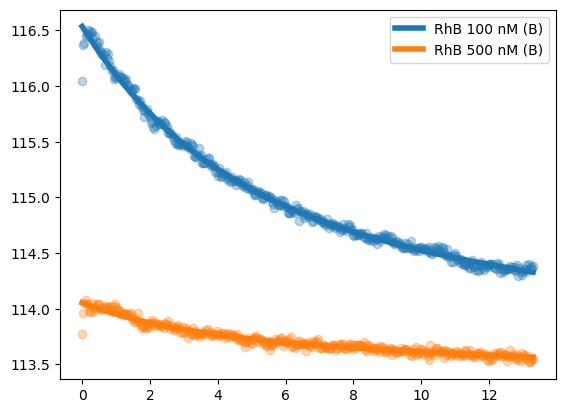

In [140]:
for i,f in enumerate(path_f8):
    j, k = divmod(i, 3)
    df_results = pd.read_csv(f)
    sample = f.split('\\')[-3].replace('Rhodamine-B', 'RhB').replace(' 140525', '')
    plt.plot(df_results['time'], df_results['avg_counts'], 'o', alpha=0.3, color=colors[i])
    plt.plot(df_results['time'], df_results['fit_exp'], '-', color=colors[i], ms=10, lw=4, label=sample)
plt.legend()

# Long measurements

In [204]:
long_measurements = [
    'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 10 nM 140525\\04-filt7-575nm\\results_roi.csv',
    'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 100 nM 140525 (A)\\03-filt7-575nm\\results_roi.csv',
]

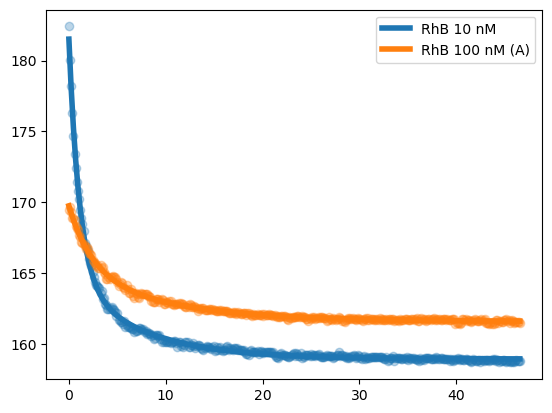

In [205]:
for i,f in enumerate(long_measurements):
    j, k = divmod(i, 3)
    df_results = pd.read_csv(f)
    sample = f.split('\\')[-3].replace('Rhodamine-B', 'RhB').replace(' 140525', '')
    plt.plot(df_results['time'], df_results['avg_counts'], 'o', alpha=0.3, color=colors[i])
    plt.plot(df_results['time'], df_results['fit_exp'], '-', color=colors[i], ms=10, lw=4, label=sample)
plt.legend()

# Filter 4 and 5

In [9]:
path_filter_5 = r'C:\Users\owner\Documents\offline_data\img\time\22-05-25\Rhodamine-B 500 nM 140525 (B)\01-filt5-527nm\results_roi.csv'
df_filter_5 = pd.read_csv(path_filter_5)

path_filter_4 = r'C:\Users\owner\Documents\offline_data\img\time\22-05-25\Rhodamine-B 500 nM 140525 (B)\02-filt4-500nm\results_roi.csv'
df_filter_4 = pd.read_csv(path_filter_4)

path_filter_8 = r'C:\Users\owner\Documents\offline_data\img\time\20-05-25\Rhodamine-B 500 nM 140525 (B)\03-filt8-605nm\results_roi.csv'
df_filter_8 = pd.read_csv(path_filter_8)

path_filter_7 = r'C:\Users\owner\Documents\offline_data\img\time\20-05-25\Rhodamine-B 500 nM 140525 (B)\01-filt7-575nm\results_roi.csv'
df_filter_7 = pd.read_csv(path_filter_7)

path_filter_6 = r'C:\Users\owner\Documents\offline_data\img\time\20-05-25\Rhodamine-B 500 nM 140525 (B)\02-filt6-550nm\results_roi.csv'
df_filter_6 = pd.read_csv(path_filter_6)

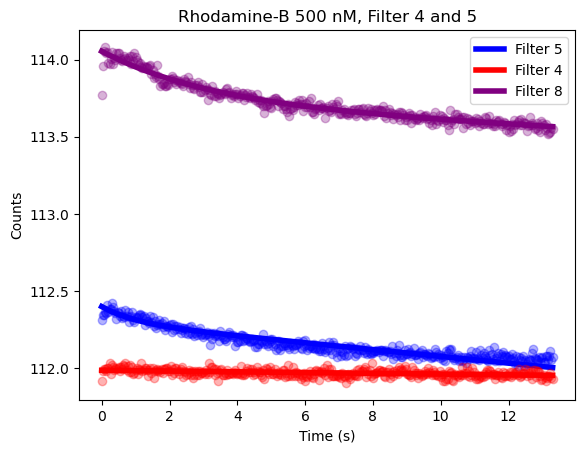

In [10]:
plt.plot(df_filter_5['time'], df_filter_5['avg_counts'], 'o', alpha=0.3, color='blue')
plt.plot(df_filter_5['time'], df_filter_5['fit_exp'], '-', color='blue', ms=10, lw=4, label='Filter 5')
plt.plot(df_filter_4['time'], df_filter_4['avg_counts'], 'o', alpha=0.3, color='red')
plt.plot(df_filter_4['time'], df_filter_4['fit_exp'], '-', color='red', ms=10, lw=4, label='Filter 4')

plt.plot(df_filter_8['time'], df_filter_8['avg_counts'], 'o', alpha=0.3, color='purple')
plt.plot(df_filter_8['time'], df_filter_8['fit_exp'], '-', color='purple', ms=10, lw=4, label='Filter 8')

plt.gca().set(xlabel='Time (s)', ylabel='Counts', title='Rhodamine-B 500 nM, Filter 4 and 5')
plt.legend()

## Compare all filters

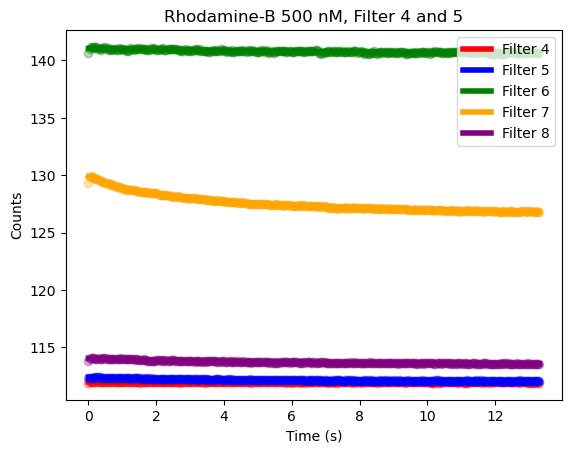

In [11]:
plt.plot(df_filter_4['time'], df_filter_4['avg_counts'], 'o', alpha=0.3, color='red')
plt.plot(df_filter_4['time'], df_filter_4['fit_exp'], '-', color='red', ms=10, lw=4, label='Filter 4')
plt.plot(df_filter_5['time'], df_filter_5['avg_counts'], 'o', alpha=0.3, color='blue')
plt.plot(df_filter_5['time'], df_filter_5['fit_exp'], '-', color='blue', ms=10, lw=4, label='Filter 5')

plt.plot(df_filter_6['time'], df_filter_6['avg_counts'], 'o', alpha=0.3, color='green')
plt.plot(df_filter_6['time'], df_filter_6['fit_exp'], '-', color='green', ms=10, lw=4, label='Filter 6')
plt.plot(df_filter_7['time'], df_filter_7['avg_counts'], 'o', alpha=0.3, color='orange')
plt.plot(df_filter_7['time'], df_filter_7['fit_exp'], '-', color='orange', ms=10, lw=4, label='Filter 7')
plt.plot(df_filter_8['time'], df_filter_8['avg_counts'], 'o', alpha=0.3, color='purple')
plt.plot(df_filter_8['time'], df_filter_8['fit_exp'], '-', color='purple', ms=10, lw=4, label='Filter 8')

plt.gca().set(xlabel='Time (s)', ylabel='Counts', title='Rhodamine-B 500 nM, Filter 4 and 5')
plt.legend()

## Reconstruct spectrum across time

In [12]:
filter_centers = [500, 527, 549, 575, 605]
filter_ranges = np.array([29, 22, 21, 35, 22])/2

In [13]:
time_spectrum = pd.DataFrame()
for i in range(len(df_filter_7)):
    spectrum = []
    for f in [df_filter_4, df_filter_5, df_filter_6, df_filter_7, df_filter_8]:
        spectrum.append(f['avg_counts'][i])
    time_spectrum = pd.concat([time_spectrum, pd.Series(spectrum)], axis=1)

time_spectrum = time_spectrum.T
time_spectrum.index = df_filter_7['time']
time_spectrum.columns = ['Filter 4', 'Filter 5', 'Filter 6', 'Filter 7', 'Filter 8']

In [316]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib

In [315]:
%matplotlib inline

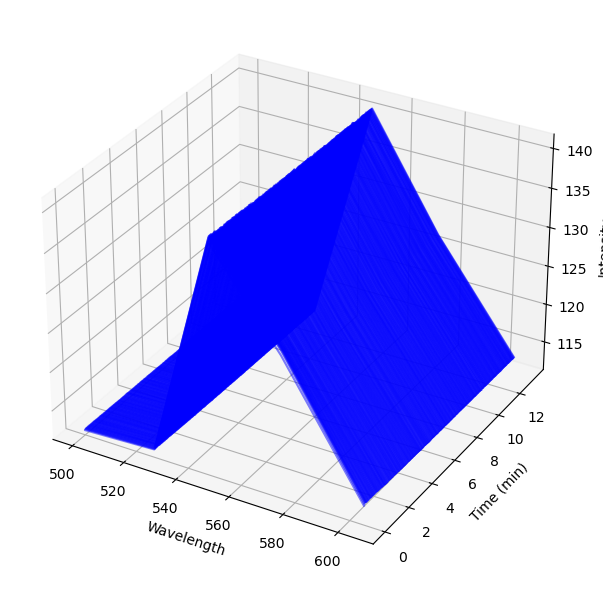

In [24]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Loop over each time point (spectrum)
for idx, row in time_spectrum.iterrows():
    y = [idx] * len(filter_centers)
    ax.plot(filter_centers, y, row, color='blue', alpha=0.5)

# Label axes
ax.set_xlabel('Wavelength')
ax.set_ylabel('Time (min)')
ax.set_zlabel('Intensity')

# Optional: Adjust view
# ax.view_init(elev=0, azim=-20)

plt.tight_layout()
plt.show()

In [20]:
time_spectrum.index

Float64Index([               0.0, 0.0333333333333333, 0.0666666666666666,
                             0.1, 0.1333333333333333, 0.1666666666666666,
                             0.2, 0.2333333333333333, 0.2666666666666666,
                             0.3,
              ...
                            13.0, 13.033333333333331, 13.066666666666666,
                            13.1, 13.133333333333333, 13.166666666666666,
                            13.2, 13.233333333333333, 13.266666666666667,
                            13.3],
             dtype='float64', name='time', length=400)

In [25]:
import plotly.graph_objects as go

fig = go.Figure()
for idx, row in time_spectrum.iterrows():
    y = [idx] * len(filter_centers)
    fig.add_trace(go.Scatter3d(
        x=filter_centers,
        y=y,
        z=row,
        mode='lines',
        line=dict(width=2),
        opacity=0.6
    ))
fig.update_layout(
    scene=dict(
        xaxis_title='Wavelength',
        yaxis_title='Time',
        zaxis_title='Intensity'
    )
)
fig.show()

# Checking Fits parameters

In [134]:
results_fit = []
results_fit.append(glob(path14 + '**/**/fit_roi_info.json'))
results_fit.append(glob(path15 + '**/**/fit_roi_info.json'))
results_fit.append(glob(path20 + '**/**/fit_roi_info.json'))
results_fit = [item for sublist in results_fit for item in sublist]
results_fit

['C:\\Users\\owner\\Documents\\offline_data\\img\\time\\14-05-25\\Rhodamine-B 500 nM 140525 (A)\\03-filt7-575nm\\fit_roi_info.json',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\14-05-25\\Rhodamine-B 500 nM 140525 (A)\\04-filt6-550nm\\fit_roi_info.json',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 1 µM 140525 (B)\\01-filt6-550nm\\fit_roi_info.json',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 1 µM 140525 (B)\\02-filt7-575nm\\fit_roi_info.json',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 10 nM 140525\\01-filt7-575nm\\fit_roi_info.json',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 10 nM 140525\\02-filt6-550nm_lights_off\\fit_roi_info.json',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\Rhodamine-B 10 nM 140525\\03-filt6-550nm_lights_on\\fit_roi_info.json',
 'C:\\Users\\owner\\Documents\\offline_data\\img\\time\\15-05-25\\R

In [189]:
fits_df = pd.DataFrame()

for file in results_fit:
    sample = file.split('\\')[-3].replace('140525', '') + '---' + file.split('\\')[-2]
    
    with open(file, 'r') as f:
        data = json.load(f)
    fit_pars = data['fit_pars']
    dft = pd.DataFrame(fit_pars.items(), columns=['param', sample]).set_index('param').T
    fits_df = pd.concat([fits_df, dft], ignore_index=False)
fits_df


param,a,t1,b,t2,I0
Rhodamine-B 500 nM (A)---03-filt7-575nm,111.562873,9487.452418,0.407191,3.139179,0.666587
Rhodamine-B 500 nM (A)---04-filt6-550nm,0.538982,6.273939,0.117721,1.087261,112.000189
Rhodamine-B 1 µM (B)---01-filt6-550nm,0.508011,11.944620,0.094504,2.224881,111.918110
Rhodamine-B 1 µM (B)---02-filt7-575nm,1.124147,10.070297,0.326902,0.762066,126.765308
Rhodamine-B 10 nM ---01-filt7-575nm,0.894898,4.959781,0.815942,0.628613,125.253266
Rhodamine-B 10 nM ---02-filt6-550nm_lights_off,0.332362,3.243537,-0.317952,0.172823,142.553171
Rhodamine-B 10 nM ---03-filt6-550nm_lights_on,3.144243,1718.546955,0.204808,3.574057,139.711762
Rhodamine-B 10 nM ---04-filt7-575nm,5.794094,7.140984,16.770170,1.082375,158.946459
Rhodamine-B 100 nM (A)---01-filt6-550nm,1260.288710,20903.760603,1.676748,2.530204,-1132.565158
Rhodamine-B 100 nM (A)---02-filt7-575nm,0.480046,6.002903,-0.562971,0.024287,146.052647


# Refitting

In [170]:
from scipy.optimize import curve_fit
def exp_func2(x, a, b, c, d, e):
    return a * np.exp(-x / b) + c * np.exp(-x / d) + e

In [222]:
def refit_trajectory(results_roi, p0 = None, bounds = None):

    bs = results_roi['avg_counts'].iloc[-1]
    init_i = results_roi['avg_counts'].max() - bs

    if p0 is None:
        p0 = (init_i, 7.23, 0.01*init_i, 0.775, bs)
    if bounds is None:
        bounds = ([0, 0, 0, 0, 100], [np.inf, np.inf, init_i, np.inf, np.inf])
    # Fit the data to the model
    time_array = results_roi['time'].values
    
    par2, _ = curve_fit(exp_func2, time_array, results_roi['avg_counts'],  p0=p0, bounds=bounds)
    results_roi['fit_exp'] = exp_func2(results_roi['time'], *par2)

    return results_roi, par2

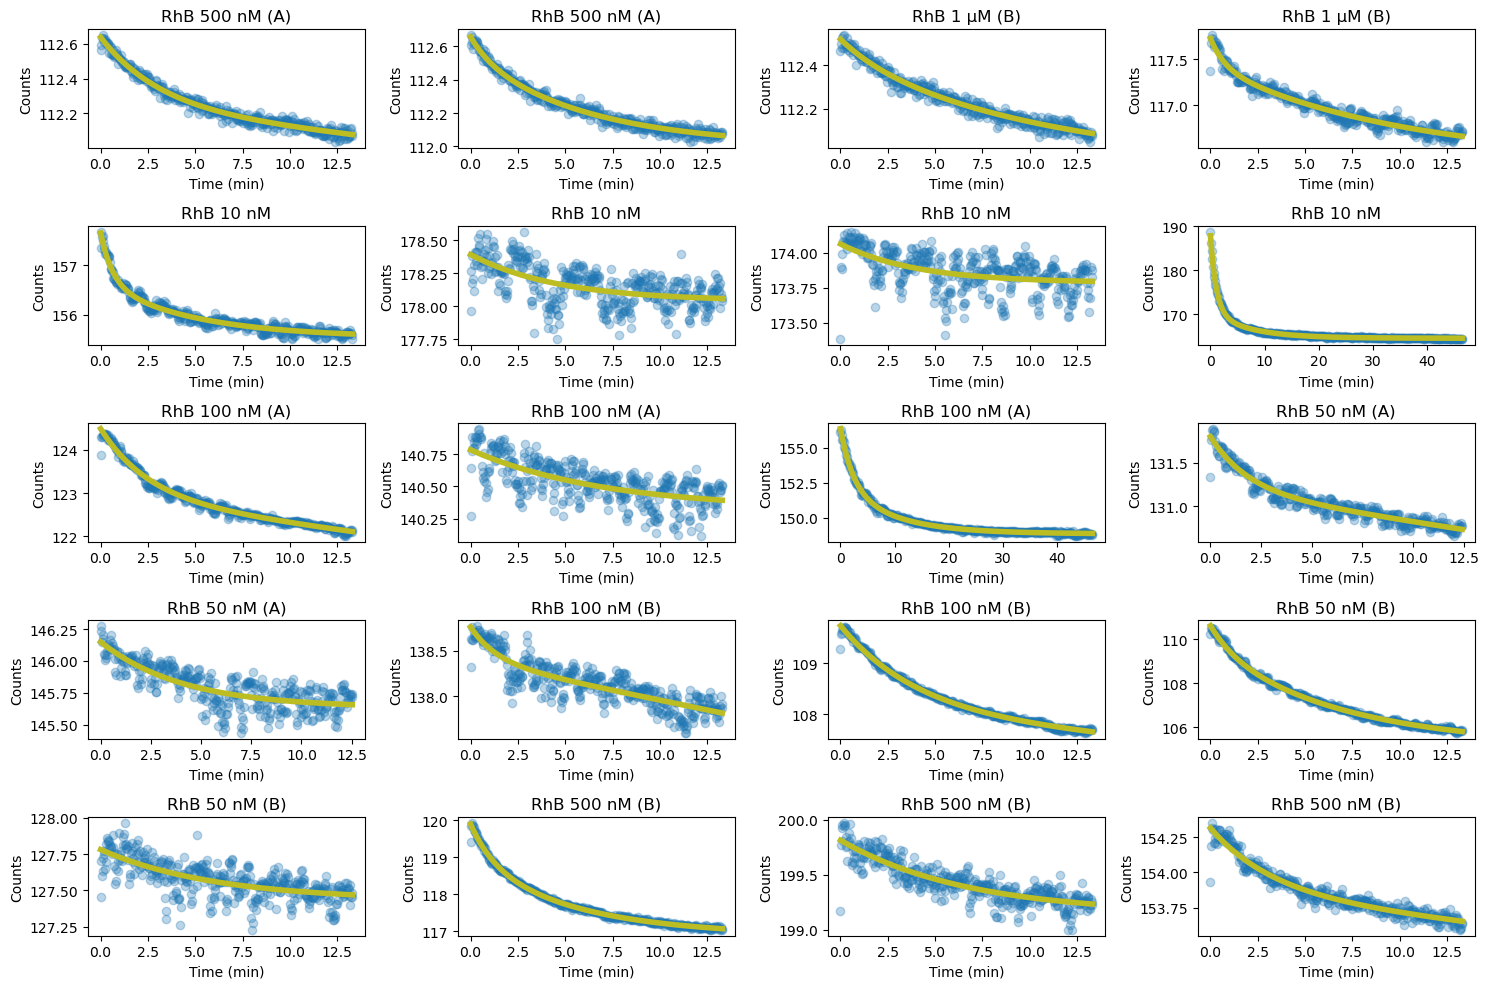

In [223]:
fits_df = pd.DataFrame()

fig, ax = plt.subplots(5, 4, figsize=(15, 10))
for i, f in enumerate(results_files):
    # print(f)
    j, k = divmod(i, 4)
    df_results, sample_name = read_results(f, powers)
    ax[j,k].plot(df_results['time'], df_results['avg_counts'], 'o', alpha=0.3)
    try:
        df_results, pars2 = refit_trajectory(df_results)
        
        dft = pd.DataFrame([pars2], columns=['a', 't1', 'b', 't2', 'I0'], index=[sample_name])
        fits_df = pd.concat([fits_df, dft], ignore_index=False)
        ax[j,k].plot(df_results['time'], df_results['fit_exp'], '-', color=col, ms=10, lw=4, label=sample_name)
    except:
        print('Error in fitting', f)
        continue
    ax[j,k].set(xlabel='Time (min)', ylabel='Counts' ,title = sample_name)
plt.tight_layout()

In [224]:
fits_df

,a,t1,b,t2,I0
RhB 500 nM (A),12.230260,1029.297701,4.063920e-01,3.135712,100.000000
RhB 500 nM (A),0.538976,6.274126,1.177292e-01,1.087359,112.000185
RhB 1 µM (B),0.507996,11.942197,9.447370e-02,2.224618,111.918155
RhB 1 µM (B),1.032142,10.070311,3.001462e-01,0.762102,116.390787
RhB 10 nM,1.111231,4.959770,1.013186e+00,0.628611,155.532002
RhB 10 nM,0.353707,4.649863,8.579623e-09,3.253203,178.037288
RhB 10 nM,0.265225,4.061342,1.324439e-02,4.060851,173.785464
RhB 10 nM,5.997089,7.140998,1.735775e+01,1.082376,164.515420
RhB 100 nM (A),22.883496,383.544834,1.603653e+00,2.520413,100.000000
RhB 100 nM (A),0.463031,7.108219,2.236326e-07,6.951320,140.321808


In [225]:
fits_df.iloc[10]

a       3.379158
t1      9.724549
b       4.140190
t2      2.358045
I0    148.848278
Name: RhB 100 nM (A), dtype: float64

In [226]:
df_results['avg_counts'].iloc[0], df_results['avg_counts'].iloc[-1], 

(153.9337709653333, 153.636130208)

In [227]:
exp_func2(0, *pars2)

154.31472203170438

# Characterize current light insulation:

Compare runs with lights off (01) and on (02)

In [66]:
path_lights_off = 'G:/My Drive/Ba Tagging/data/img/time/20-05-25\\Rhodamine-B 10 nM 140525\\01\\results_roi.csv'
path_lights_on = 'G:/My Drive/Ba Tagging/data/img/time/20-05-25\\Rhodamine-B 10 nM 140525\\02\\results_roi.csv'

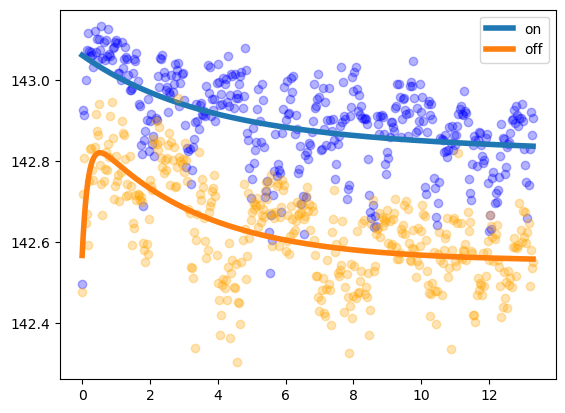

In [85]:
df_on = pd.read_csv(path_lights_on)
col = plt.plot(df_on['time'], df_on['avg_counts'], 'bo', alpha=0.3)[0].get_color()
plt.plot(df_on['time'], df_on['fit_exp'], '-', ms=10, lw=4, label='on')

df_off = pd.read_csv(path_lights_off)
col = plt.plot(df_off['time'], df_off['avg_counts'], 'o', color='orange', alpha=0.3)[0].get_color()
plt.plot(df_off['time'], df_off['fit_exp'], '-', ms=10, lw=4, label='off')

plt.legend()

# Test autoscale image display

In [5]:
ROOT_DIR = r'C:\Users\owner\Documents\sabbath\microscope_control'
TEST_IMAGE = ROOT_DIR + '\\test_image-Center-575nm_Width-35nm__P_378.4uW_frame_000.tif'
from skimage import io
from skimage.exposure import equalize_hist 
img = io.imread(TEST_IMAGE).astype(np.int16)
imgg = equalize_hist(img)

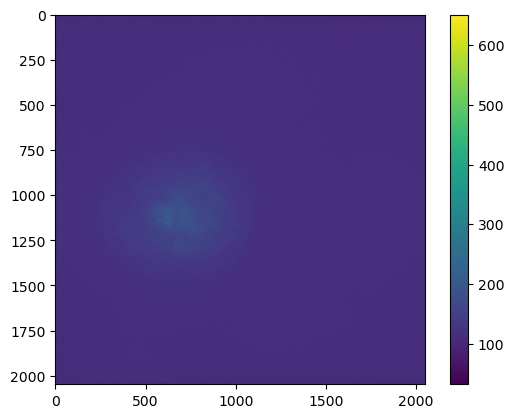

In [8]:
plt.imshow(img)
plt.colorbar()

<BarContainer object of 1000 artists>

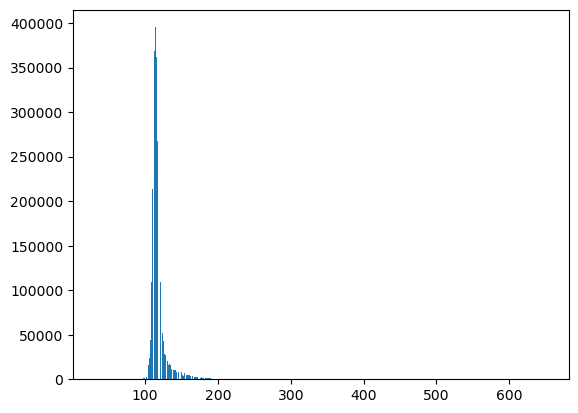

In [9]:
n, bins = np.histogram(img.flatten(), bins=1000)
cbins = (bins[:-1] + bins[1:]) / 2
plt.bar(cbins, n)

In [10]:
cbins[n>7].max()

258.8635

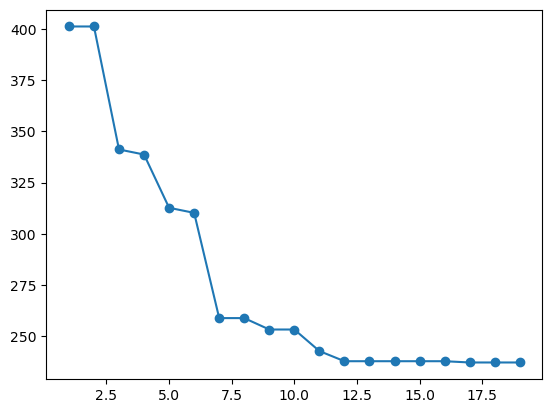

In [11]:
cbins[n>8]
max_counts = []
for i in range(1, 20):
    max_counts.append(cbins[n>i].max())
plt.plot(range(1, 20), max_counts, 'o-')

In [12]:
def get_cutoff(img, threshold=8):
    n, bins = np.histogram(img.flatten(), bins=int(img.shape[0]/2) )
    cbins = (bins[:-1] + bins[1:]) / 2
    return cbins[n>threshold].max()

get_cutoff(img, threshold=7)

258.98681640625

651 (1242, 1265) 258.8635


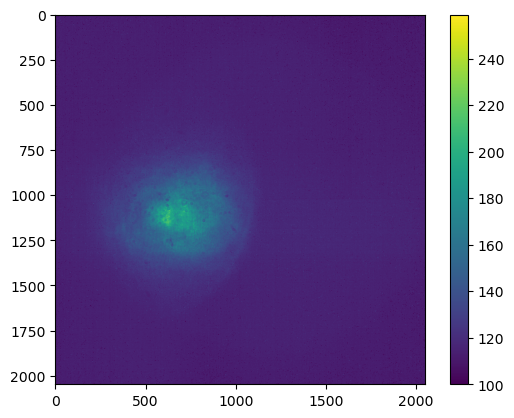

In [13]:
n, bins = np.histogram(img.flatten(), bins=1000)
cutoff = cbins[n>7].max()
px_max = np.unravel_index(np.argmax(img, axis=None), img.shape)
print(img[px_max], px_max, cutoff)

imgf = img.copy()
imgf[imgf > cutoff] = cutoff
imgf[imgf < 100] = 0
plt.imshow(imgf, clim=(100, cutoff-0))
plt.colorbar()

# Check ROI

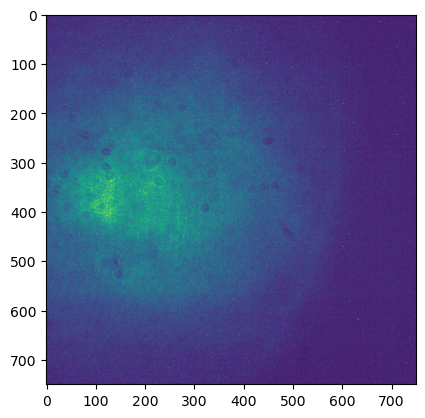

In [ ]:
roi = [750, 1500, 500, 1250]
im_roi = img[roi[0]:roi[1], roi[2]:roi[3]]
plt.imshow(im_roi, clim=(100, cutoff-0))

In [25]:
def draw_roi(ax, roi):
    # Draw a rectangle on the image based on the ROI coordinates
    top_left = (roi[2], roi[0])
    width = roi[1] - roi[0]
    height = roi[3] - roi[2]
    dynamic_rect = plt.Rectangle(top_left, width, height, edgecolor='red',
                                    facecolor='none', linewidth=2)
    ax.add_patch(dynamic_rect)


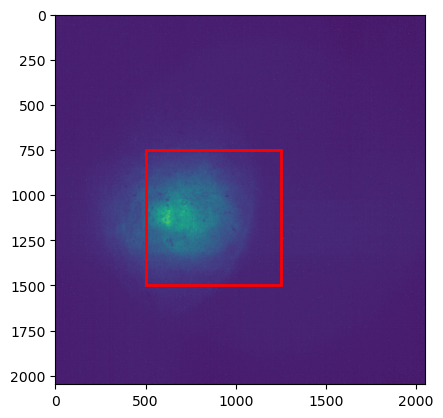

In [26]:
roi = [750, 1500, 500, 1250]

plt.imshow(img, clim=(100, cutoff), )
draw_roi(plt.gca(), roi)

In [148]:
FILTERS = \
    {
        1: "Center-NA_Width-NA",
        2: "Dark_Blind",
        3: "Center-438nm_Width-28nm",
        4: "Center-500nm_Width-29nm",
        5: "Center-527nm_Width-22nm",
        6: "Center-549nm_Width-21nm",
        7: "Center-575nm_Width-35nm",
        8: "Center-605nm_Width-22nm",
        9: "Center-631nm_Width-28nm",
        10: "Center-661nm_Width-26nm",
        11: "Center-676nm_Width-29nm",
        12: "Center-692nm_Width-47nm"
    }